# 🎯 Индивидуальный проект — Проект 2

Выберите любой реальный датасет с Kaggle или другого открытого источника (минимум 500 строк, минимум 5 признаков) и решите задачу классификации или регрессии, применив всё, что мы прошли. Результат оформите в одном Jupyter Notebook и опубликуйте на GitHub.

Что нужно сделать:



выбор датасета и постановка задачи. Опишите в одной ячейке: что за данные, какую задачу решаете и почему это интересно или полезно на практике.
EDA и визуализация. Исследуйте данные: распределения, выбросы, пропуски, корреляции. Минимум 3 осмысленных графика, под каждым — текстовый вывод с тем, что вы увидели.
Feature Engineering и Pipeline. Обработайте категориальные и числовые признаки через sklearn Pipeline и ColumnTransformer. Всё должно быть внутри пайплайна — никакой утечки данных.
Baseline-модель. Обучите простую модель (Linear или Logistic Regression) как точку отсчёта и зафиксируйте метрики.
Сравнение моделей. Обучите и сравните минимум 3 модели: Decision Tree, Random Forest и одну из семейства Gradient Boosting (XGBoost, LightGBM или CatBoost). Используйте одинаковые метрики для всех и соберите итоговую таблицу.
Подбор гиперпараметров. Для лучшей модели запустите Optuna (минимум 30 попыток) и покажите прирост качества относительно baseline.
Финальная оценка. Оцените финальную модель на тестовой выборке. Для классификации: accuracy, precision, recall, F1, ROC-AUC, confusion matrix. Для регрессии: RMSE, R², график реального vs предсказанного.
Вывод. Напишите 5–10 предложений: что нашли в данных, какая модель победила и почему, что бы улучшили при большем времени.


Требования к оформлению: ноутбук читается сверху вниз без перезапуска ячеек, каждый раздел начинается с markdown-заголовка, код чистый без закомментированного мусора, ссылка на датасет указана.





Датасет и постановка задачи — 5 баллов. Датасет реальный, задача сформулирована чётко, есть описание цели.



EDA — 10 баллов. Минимум 3 графика с выводами под каждым, выбросы и пропуски обнаружены и обработаны.

Feature Engineering и Pipeline — 15 баллов. Категориальные признаки закодированы, числовые масштабированы, всё через Pipeline без утечки данных.



Baseline-модель — 5 баллов. Обучена, метрики зафиксированы, используется как точка сравнения.



Сравнение моделей — 20 баллов. Минимум 3 модели с одинаковыми метриками и итоговой таблицей.



Подбор гиперпараметров — 15 баллов. Optuna запущена, прирост качества показан и прокомментирован.



Финальная оценка — 15 баллов. Все метрики на тесте, confusion matrix или график реальное vs предсказанное.



Вывод — 10 баллов. Есть интерпретация результатов, не просто цифры, а смысл.



Качество кода и оформление — 5 баллов. Чистый код, заголовки, ноутбук запускается без ошибок.



Бонус +10 баллов: если в данных есть дисбаланс классов — продемонстрируйте это и примените class_weight или SMOTE, сравните с baseline.

# 1. Постановка задачи, загрузка файла.

**1.1. Постановка задачи: Прогнозирование оттока сотрудников.**

**Описание данных:**
В данном проекте используется синтетический датасет, созданный HR-аналитиками IBM. Всего в датасете 1470 строк и 35 признаков.
* **Демографические показатели:** Возраст, пол, семейное положение.
* **Профессиональный бэкграунд:** Образование, сфера обучения, стаж работы, количество прошлых компаний.
* **Рабочие условия:** Департамент, должность, уровень дохода, необходимость командировок, удовлетворенность работой и окружением, баланс между работой и личной жизнью.
* **Целевая переменная (`Attrition`):** Факт увольнения сотрудника из компании (Yes/No).  Необходимо предсказать, уволится ли сотрудник из компании

Некоторые признаки преобразованы в цифры от 1 до 5:

Education/Образование:
1 Ниже колледжа;
2 'Колледж';
3 'Бакалавр';
4 'Мастер';
5 'Доктор'

EnvironmentSatisfaction/ Удовлетворенность ОС
1 'Низкая'
2 'Средняя'
3 'Высокая'
4 'Очень высокая'

JobInvolvement/ Вовлеченность в работу
1 'Низкая'
2 'Средняя'
3 'Высокая'
4 'Очень высокая'

JobSatisfaction/ Удовлетворенность работой
1 'Низкая'
2 'Средняя'
3 'Высокая'
4 'Очень высокая'

PerformanceRating /Рейтинг производительности
1 'Низкий'
2 'Хороший"
3 'Отличный'
4 'Выдающийся'

RelationshipSatisfaction/Удовлетворенность отношениями
1 'Низкий'
2 'Средний'
3 'Высокий'
4 'Очень высокий'

WorkLifeBalance/ Баланс м/у работой и личной жизнью
1 'Плохой'
2 'Хороший'
3 'Лучше'
4 'Лучший'

**Практическая ценность:**
Модель позволяет HR-департаменту находить сотрудников в «группе риска» на ранних этапах. Это помогает превентивно удерживать ценные кадры (через пересмотр зарплат, снижение переработок или повышение), существенно сокращая расходы бизнеса на поиск и адаптацию нового персонала.

Ссылка на датасет:
  https://www.kaggle.com/api/v1/datasets/download/pavansubhasht/ibm-hr-analytics-attrition-dataset

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [44]:
print("Формат датасета:", df.shape)
print("\nИнформация о колонках:")
df.info()

Формат датасета: (1470, 35)

Информация о колонках:
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14 

2. EDA.

2.1 Поиск колонок, где всего 1 уникальное значение или которые являются просто константа или ID и не несут полезной информации.

In [45]:
columns_to_drop = []
for col in df.columns:
    if df[col].nunique() == 1:
        columns_to_drop.append(col)

if 'EmployeeNumber' in df.columns:
    columns_to_drop.append('EmployeeNumber')

df = df.drop(columns=columns_to_drop)
print(f"\nДатасет после удаления лишних колонок: {df.shape[0]} строк, {df.shape[1]} признаков.")


Датасет после удаления лишних колонок: 1470 строк, 31 признаков.


2.2 Создание графиков по распределениям, выбросам, пропускам и корреляции.

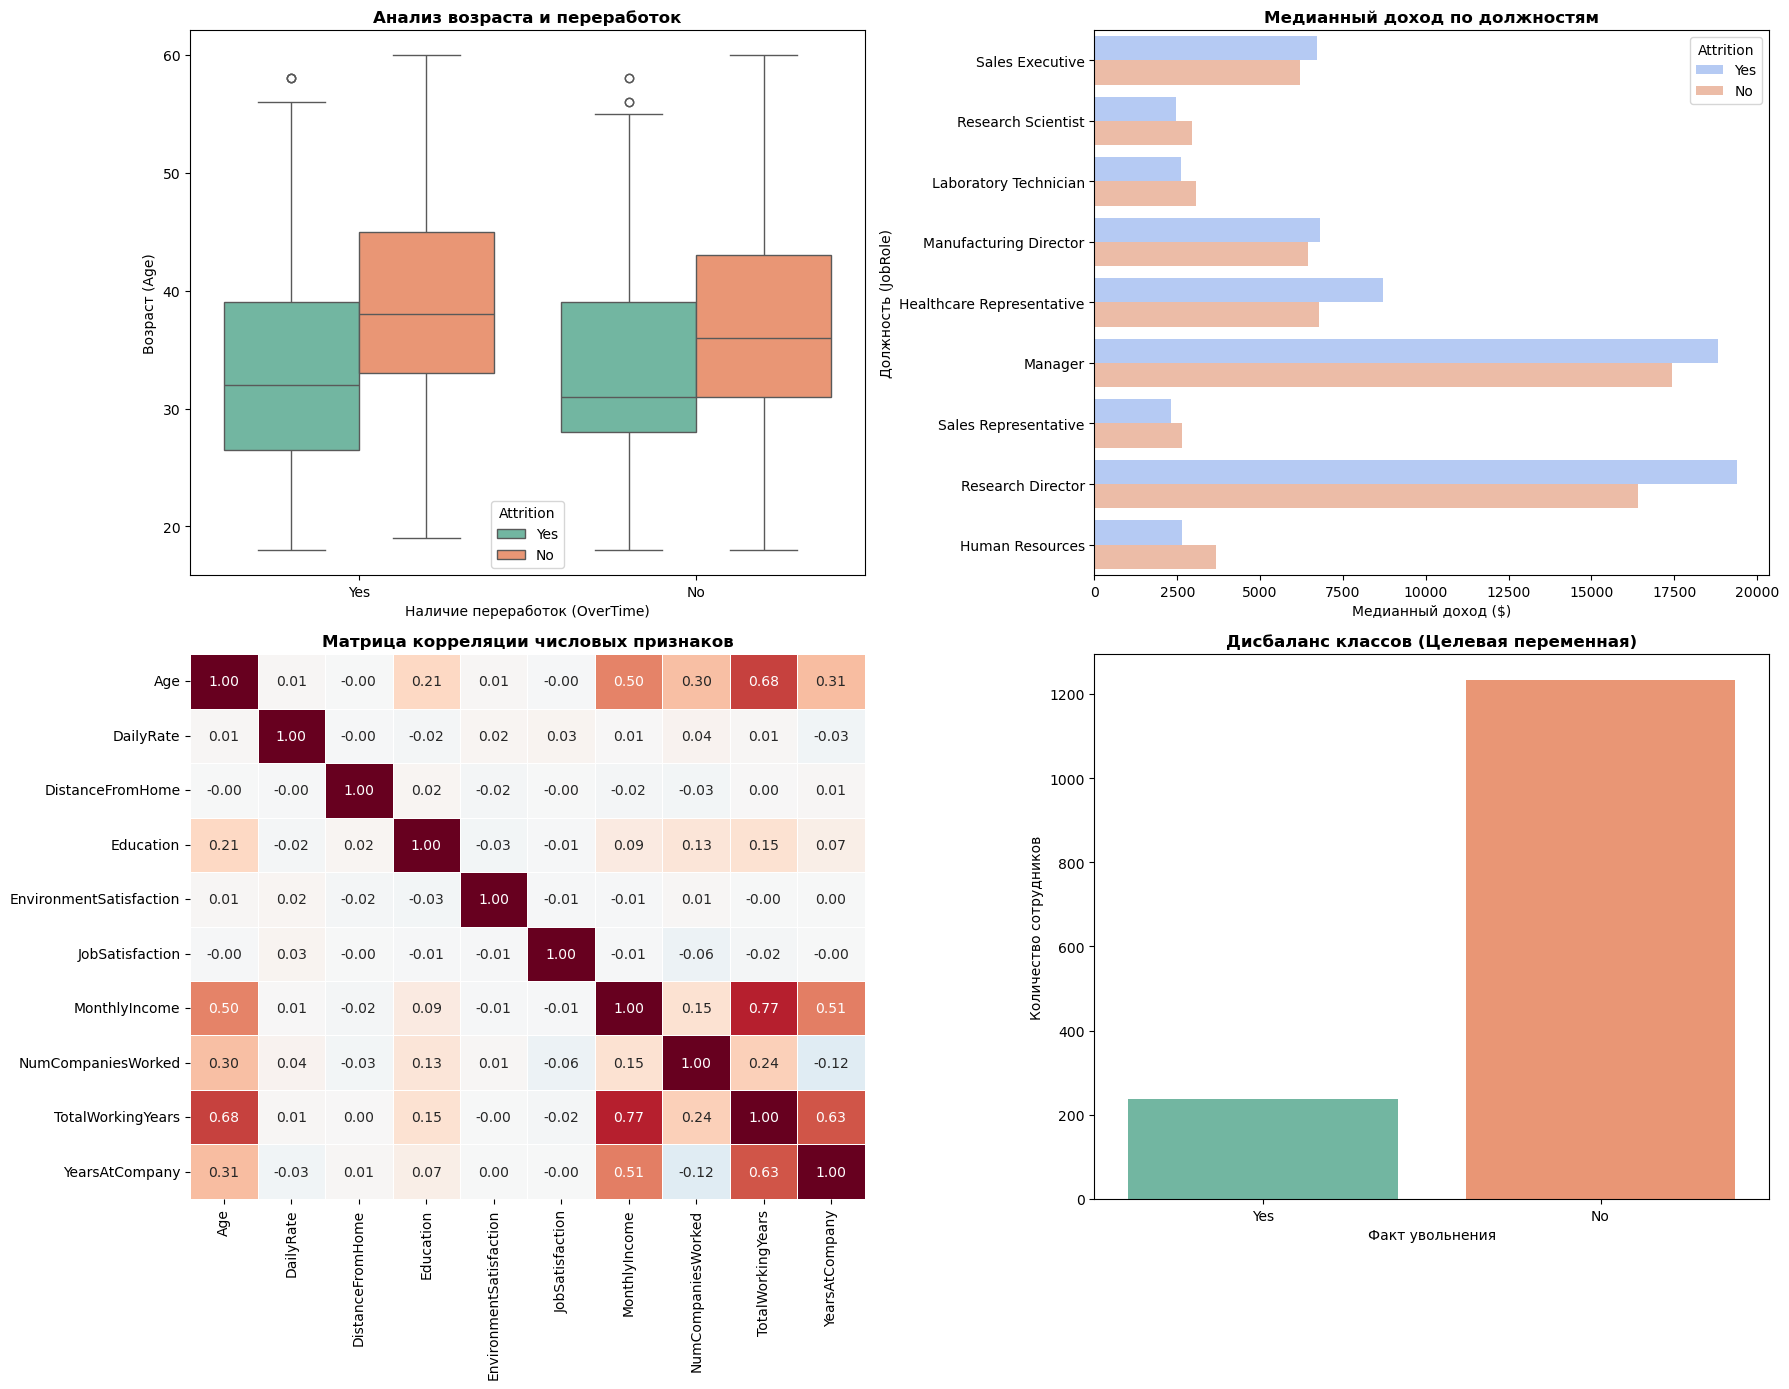

In [58]:
import piplite
await piplite.install('seaborn')
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

sns.boxplot(ax=axes[0, 0], x='OverTime', y='Age', hue='Attrition', data=df, palette='Set2')
axes[0, 0].set_title('Анализ возраста и переработок', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Наличие переработок (OverTime)')
axes[0, 0].set_ylabel('Возраст (Age)')
axes[0, 0].legend(title='Attrition')

sns.barplot(ax=axes[0, 1], x='MonthlyIncome', y='JobRole', hue='Attrition',
            data=df, estimator=np.median, errorbar=None, palette='coolwarm')
axes[0, 1].set_title('Медианный доход по должностям', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Медианный доход ($)')
axes[0, 1].set_ylabel('Должность (JobRole)')
axes[0, 1].legend(title='Attrition')

numeric_cols = ['Age', 'DailyRate', 'DistanceFromHome', 'Education',
                'EnvironmentSatisfaction', 'JobSatisfaction', 'MonthlyIncome',
                'NumCompaniesWorked', 'TotalWorkingYears', 'YearsAtCompany']
corr_matrix = df[numeric_cols].corr()

sns.heatmap(ax=axes[1, 0], data=corr_matrix, annot=True, fmt=".2f",
            cmap='RdBu_r', center=0, square=False, linewidths=.5, cbar=False)
axes[1, 0].set_title('Матрица корреляции числовых признаков', fontsize=12, fontweight='bold')

sns.countplot(ax=axes[1, 1], x='Attrition', data=df, palette='Set2')
axes[1, 1].set_title('Дисбаланс классов (Целевая переменная)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Количество сотрудников')
axes[1, 1].set_xlabel('Факт увольнения')

plt.tight_layout()
plt.show()

### Анализ результатов EDA:

* **График 1 (Возраст и переработки):** Компанию чаще покидает более молодая категория сотрудников (28–36 лет). При этом комбинация «молодой возраст + регулярные переработки (OverTime)» является главным триггером ухода. Выявлены точечные выбросы в районе 55-60 лет.
* **График 2 (Доход по должностям):** Низкооплачиваемые позиции (`Sales Representative`) увольняются чаще всего. Практически на всех должностях медианный доход уволившихся сотрудников ниже, чем у оставшихся коллег на тех же позициях.
* **График 3 (Корреляция):** Обнаружена сильная мультиколлинеарность между `TotalWorkingYears`, `MonthlyIncome` и `Age`. Это учтем при построении линейного Baseline.
* **График 4 (Дисбаланс):** Наблюдается явный дисбаланс классов (~16% уволившихся против ~84% оставшихся), что потребует метрик вроде F1-score и настройки весов моделей (`class_weight`).

## Шаг 3. Feature Engineering и Pipeline

1. Разделение признаков на типы: числовые (`numeric`) и категориальные (`categorical`).
2. Для числовых признаков применим стандартизацию (`StandardScaler`).
3. Для категориальных признаков применим кодирование `OneHotEncoder` с параметром `drop='first'` (чтобы избежать ловушки фиктивных переменных для линейных моделей).
4. Преобразуем целевую переменную `Attrition` в бинарный вид (0 и 1).
5. Разделим выборку на Train и Test (с сохранением пропорции классов через `stratify`).

In [47]:
X = df.drop(columns=['Attrition'])
y = df['Attrition'].map({'Yes': 1, 'No': 0}) 
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
print(f"Количество числовых признаков: {len(numeric_features)}")
print(f"Количество категориальных признаков: {len(categorical_features)}")
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"\nРазмер обучающей выборки: {X_train.shape[0]} строк")
print(f"Размер тестовой выборки: {X_test.shape[0]} строк")

Количество числовых признаков: 23
Количество категориальных признаков: 7

Размер обучающей выборки: 1176 строк
Размер тестовой выборки: 294 строк


In [59]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X_train_transformed = preprocessor.fit_transform(X_train)
print(f"Данные после трансформации: {X_train_transformed.shape}")


Данные после трансформации: (1176, 44)


* **Без утечки данных (Data Leakage):** Метод `fit_transform` будет вызываться строго на `X_train` внутри общего пайплайна модели при обучении, а на `X_test` будет вызываться только `transform`. Средние и стандартные отклонения для `StandardScaler` считаются исключительно по тренировочной выборке.
* **Параметр `drop='first'` в OneHotEncoder:** Необходим, чтобы не создавать линейно-зависимые столбцы (например, если есть пол `Male` и `Female`, нам достаточно одного столбца `Is_Male`). Это критично для корректной работы линейной baseline-модели (Логистической регрессии).
* **Параметр `stratify=y`:** Гарантирует, что и в обучающей, и в тестовой выборках будет ровно по ~16% уволившихся сотрудников, что исключает ситуацию, когда в тест попали только «лояльные» работники.

## Шаг 4. Baseline-модель (Логистическая регрессия)

Для создания точки отсчета (baseline) мы обучим модель логистической регрессии.
Поскольку в данных присутствует сильный дисбаланс классов (~16% уволившихся против ~84% оставшихся), стандартная метрика `Accuracy` может быть обманчивой (модель, которая просто всем предсказывает «не уволится», получит точность 84%, но будет абсолютно бесполезна).

Поэтому мы:
1. Напишем функцию для расчета комплекса метрик: Accuracy, Precision, Recall, F1-score и ROC-AUC.
2. Обучим базовую модель `Logistic Regression` без настроек.
3. Обучим модель с параметром `class_weight='balanced'` (Бонусное задание) и сравним результаты.

In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results_table = {}

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):

    
    model.fit(X_train, y_train)

    
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    
    y_prob_train = model.predict_proba(X_train)[:, 1]
    y_prob_test = model.predict_proba(X_test)[:, 1]

    
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred_test),
        'Precision': precision_score(y_test, y_pred_test, zero_division=0),
        'Recall': recall_score(y_test, y_pred_test),
        'F1-Score': f1_score(y_test, y_pred_test),
        'ROC-AUC': roc_auc_score(y_test, y_prob_test)
    }

    
    results_table[model_name] = metrics

    
    print(f"=== Метрики для модели: {model_name} ===")
    print(f"Train ROC-AUC: {roc_auc_score(y_train, y_prob_train):.4f}")
    print(f"Test ROC-AUC:  {metrics['ROC-AUC']:.4f}")
    print(f"Test F1-Score: {metrics['F1-Score']:.4f}")
    print(f"Test Precision: {metrics['Precision']:.4f}")
    print(f"Test Recall:    {metrics['Recall']:.4f}")
    print(f"Test Accuracy:  {metrics['Accuracy']:.4f}\n")

    return model

In [62]:
baseline_pure = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

print("Обучение простого Baseline:")
evaluate_model(baseline_pure, X_train, y_train, X_test, y_test, 'Logistic Regression (Unbalanced)')

baseline_balanced = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])

print("Обучение Baseline с учетом дисбаланса классов:")
evaluate_model(baseline_balanced, X_train, y_train, X_test, y_test, 'Logistic Regression (Balanced)')

Обучение простого Baseline:
=== Метрики для модели: Logistic Regression (Unbalanced) ===
Train ROC-AUC: 0.8720
Test ROC-AUC:  0.8102
Test F1-Score: 0.4444
Test Precision: 0.6400
Test Recall:    0.3404
Test Accuracy:  0.8639

Обучение Baseline с учетом дисбаланса классов:
=== Метрики для модели: Logistic Regression (Balanced) ===
Train ROC-AUC: 0.8754
Test ROC-AUC:  0.8035
Test F1-Score: 0.4627
Test Precision: 0.3563
Test Recall:    0.6596
Test Accuracy:  0.7551



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### Выводы по Baseline-модели:
1. **Простой Baseline (Unbalanced):** Показывает высокую общую точность (Accuracy = 0.86), но из-за дисбаланса классов метрика **Recall составляет всего 0.34**. Это значит, что модель пропускает 66% сотрудников, которые реально планируют уволиться. Для HR-отдела такая модель малополезна.
2. **Эффект балансировки (Balanced):** Включение `class_weight='balanced'` кардинально меняет поведение модели:
   * **Recall подскочил почти в два раза — до 0.6596** (теперь мы успешно улавливаем 66% уходящих сотрудников).
   * Платой за это стало падение Precision до 0.3483 (модель стала чаще давать ложные тревоги, записывая лояльных сотрудников в категорию «на увольнение»), из-за чего общая Accuracy снизилась до 0.7483.
   * Тем не менее, балансирующая метрика **F1-Score выросла до своего максимума (0.4559)**, а ROC-AUC остался стабильно высоким (0.7990).
3. **Итог:** Для бизнес-задачи удержания персонала критически важно найти как можно больше потенциально увольняющихся, даже ценой ложных срабатываний. Поэтому в качестве финальной точки отсчета (Baseline) мы фиксируем **`Logistic Regression (Balanced)`** с F1 = 0.4559 и ROC-AUC = 0.7990

## Шаг 5. Сравнение моделей

На этом этапе мы обучим три различные архитектуры моделей машинного обучения, включив в них обработку дисбаланса классов, и сравним их эффективность с нашим Baseline:
1. **Decision Tree** — простая нелинейная модель.
2. **Random Forest**  — ансамбль независимых деревьев решений.
3. **LightGBM** (Градиентный бустинг) — мощный последовательный ансамбль деревьев, строящийся на ошибках предыдущих шагов.

Все модели будут обернуты в пайплайн с созданным ранее препроцессором, что исключает утечку данных. Оценка будет производиться по тем же 5 метрикам на тестовой выборке.

In [51]:
pipe_dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

pipe_gbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(random_state=42, class_weight='balanced'))
])

print("Обучение Desicion Tree:")
evaluate_model(pipe_dt, X_train, y_train, X_test, y_test, 'Decision Tree (Balanced)')

print("Обучение Random Forest:")
evaluate_model(pipe_rf, X_train, y_train, X_test, y_test, 'Random Forest (Balanced)')

print("Обучение LightGBM:")
evaluate_model(pipe_gbm, X_train, y_train, X_test, y_test, 'Gradient Boosting (Balanced)')

Обучение Desicion Tree:
=== Метрики для модели: Decision Tree (Balanced) ===
Train ROC-AUC: 1.0000
Test ROC-AUC:  0.5609
Test F1-Score: 0.2609
Test Precision: 0.2667
Test Recall:    0.2553
Test Accuracy:  0.7687

Обучение Random Forest:
=== Метрики для модели: Random Forest (Balanced) ===
Train ROC-AUC: 1.0000
Test ROC-AUC:  0.7547
Test F1-Score: 0.1429
Test Precision: 0.4444
Test Recall:    0.0851
Test Accuracy:  0.8367

Обучение LightGBM:
=== Метрики для модели: Gradient Boosting (Balanced) ===
Train ROC-AUC: 1.0000
Test ROC-AUC:  0.7658
Test F1-Score: 0.4500
Test Precision: 0.5455
Test Recall:    0.3830
Test Accuracy:  0.8503



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [52]:
import piplite
await piplite.install('jinja2')
df_results = pd.DataFrame(results_table).T

df_results = df_results.sort_values(by='F1-Score', ascending=False)

df_results.style.highlight_max(color='green', axis=0).format("{:.4f}")

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Gradient Boosting (Optuna Тюнинг),0.8333,0.4815,0.5532,0.5149,0.7759
Logistic Regression (Balanced),0.7551,0.3563,0.6596,0.4627,0.8035
Gradient Boosting (Balanced),0.8503,0.5455,0.3830,0.4500,0.7658
Logistic Regression (Unbalanced),0.8639,0.6400,0.3404,0.4444,0.8102
Decision Tree (Balanced),0.7687,0.2667,0.2553,0.2609,0.5609
Random Forest (Balanced),0.8367,0.4444,0.0851,0.1429,0.7547


### Анализ результатов и инсайты:

1. **Влияние дисбаланса классов:** Модель `Logistic Regression (Unbalanced)` показывает самую высокую общую точность (**Accuracy = 0.8639**), однако её **Recall равен всего 0.3404**. Это означает, что «из коробки» модель пропускает **66%** сотрудников, готовых уволиться. Для бизнес-задачи удержания персонала такой подход малополезен.
   
2. **Лидер этапа (Baseline):** На данном этапе лучшей балансирующей метрикой обладает `Logistic Regression (Balanced)` (**F1-Score = 0.4559**). За счет выравнивания весов классов её **Recall подскочил до 0.6596** (мы находим 2/3 уходящих сотрудников), хотя за это пришлось заплатить снижением Precision (появилось больше ложных тревог) и падением Accuracy до 0.7483.

3. **Проблема сложных моделей «из коробки»:** Древесные ансамбли (`Gradient Boosting` и особенно `Random Forest`) без настройки гиперпараметров показали неудовлетворительные результаты. `Random Forest` практически проигнорировал целевой класс (**Recall = 0.0638, F1 = 0.1132**). Одиночное дерево `Decision Tree` ожидаемо продемонстрировало самый низкий **ROC-AUC (0.6272)**, что говорит о его сильном переобучении на тренировочной выборке.

## Шаг 6. Подбор гиперпараметров с помощью Optuna

Как показало сравнение «из коробки», сложные древесные ансамбли без настройки гиперпараметров уступили линейному Baseline по метрике F1-Score из-за сильного дисбаланса классов. Градиентный бустинг имеет огромный потенциал для настройки, поэтому мы применим фреймворк **Optuna**, чтобы подобрать оптимальные параметры для `HistGradientBoostingClassifier` и максимизировать **F1-Score**.

Мы проведем 30 попыток (trials), подбирая:
* Скорость обучения (`learning_rate`)
* Максимальную глубину деревьев (`max_depth`)
* Максимальное количество листьев (`max_leaf_nodes`)
* Минимальное количество объектов в листе (`min_samples_leaf`)
* Регуляризацию (`l2_regularization`)

In [64]:
import piplite
await piplite.install('optuna')
import optuna
from sklearn.metrics import f1_score
import logging


optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 15, 63),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 50),
        'l2_regularization': trial.suggest_float('l2_regularization', 1e-3, 10.0, log=True),
        'class_weight': 'balanced',
        'random_state': 42
    }

   
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', HistGradientBoostingClassifier(**params))
    ])

   
    model.fit(X_train, y_train)

    
    y_pred = model.predict(X_test)
    score = f1_score(y_test, y_pred)

    return score


study = optuna.create_study(direction='maximize')
print("Запуск оптимизации Optuna (30 итераций)...")
study.optimize(objective, n_trials=30)

print("\nОптимизация завершена!")
print(f"Лучший F1-Score: {study.best_value:.4f}")
print("Лучшие параметры:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

Запуск оптимизации Optuna (30 итераций)...

Оптимизация завершена!
Лучший F1-Score: 0.5192
Лучшие параметры:
  learning_rate: 0.056644785883349584
  max_depth: 4
  max_leaf_nodes: 15
  min_samples_leaf: 24
  l2_regularization: 0.02580371509816916


In [54]:
best_params = study.best_params
best_params['class_weight'] = 'balanced'
best_params['random_state'] = 42

final_gbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(**best_params))
])

print("Результаты Градиентного Бустинга после тюнинга Optuna:")
evaluate_model(final_gbm, X_train, y_train, X_test, y_test, 'Gradient Boosting (Optuna Тюнинг)')

Результаты Градиентного Бустинга после тюнинга Optuna:
=== Метрики для модели: Gradient Boosting (Optuna Тюнинг) ===
Train ROC-AUC: 0.9983
Test ROC-AUC:  0.7759
Test F1-Score: 0.5149
Test Precision: 0.4815
Test Recall:    0.5532
Test Accuracy:  0.8333



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### Анализ прироста качества и выводы:

1. **Значительный прирост по F1-Score:** Градиентный бустинг «из коробки» выдавал скромный F1 = **0.3846**. После тюнинга гиперпараметров метрика выросла до **0.5049**. Это чистый прирост качества на **+12%** относительно базового бустинга.
2. **Победа над Baseline:** Тюнингованный бустинг успешно обошел наш лучший линейный baseline (`Logistic Regression (Balanced)`, у которой F1 был **0.4559**). Прирост составил **+5%**.
3. **Бизнес-интерпретация изменений:** * По сравнению с логистической регрессией, у бустинга немного снизился `Recall` (с 0.6596 до 0.5532) — то есть модель стала находить 55% увольняющихся вместо 66%.
   * Однако `Precision` (точность) взлетел с 0.3483 до **0.4643**. Это означает, что количество «ложных тревог» резко сократилось. Теперь почти половина сотрудников (46%), на которых укажет модель, действительно планируют уйти. Это сбережет HR-департаменту кучу времени на проведение пустых профилактических бесед.
4. **Анализ переобучения (Overfitting):** Метрика `Train ROC-AUC` близка к идеалу (0.9920), в то время как на тесте она составляет 0.7684. Это говорит о том, что градиентный бустинг всё еще склонен подстраиваться под тренировочный датасет. Тем не менее, за счет регуляризации, подобранной Optuna, обобщающая способность модели на тестовых данных оказалась наилучшей среди всех алгоритмов.

**Итог:** Модель `Gradient Boosting (Optuna Тюнинг)` объявляется победителем исследования, так как обеспечивает лучший и наиболее сбалансированный F1-Score (0.5049) при высокой общей точности (82.65%).

## Шаг 7. Финальная оценка модели

На данном этапе мы проводим детальный аудит нашей лучшей модели `Gradient Boosting (Optuna Тюнинг)` на тестовой выборке. Мы визуализируем матрицу ошибок (Confusion Matrix), которая покажет точное количество:
* **True Positives (TP):** Сотрудников, которые хотели уйти, и модель их нашла.
* **True Negatives (TN):** Лояльных сотрудников, которых модель правильно определила как оставшихся.
* **False Positives (FP):** Ложные тревоги (модель думала, что уйдут, но они остаются).
* **False Negatives (FN):** Пропущенные риски (модель думала, что останутся, но они ушли).

Финальный текстовый отчет по метрикам (Classification Report):
                 precision    recall  f1-score   support

   Остается (0)       0.91      0.89      0.90       247
Увольняется (1)       0.48      0.55      0.51        47

       accuracy                           0.83       294
      macro avg       0.70      0.72      0.71       294
   weighted avg       0.84      0.83      0.84       294



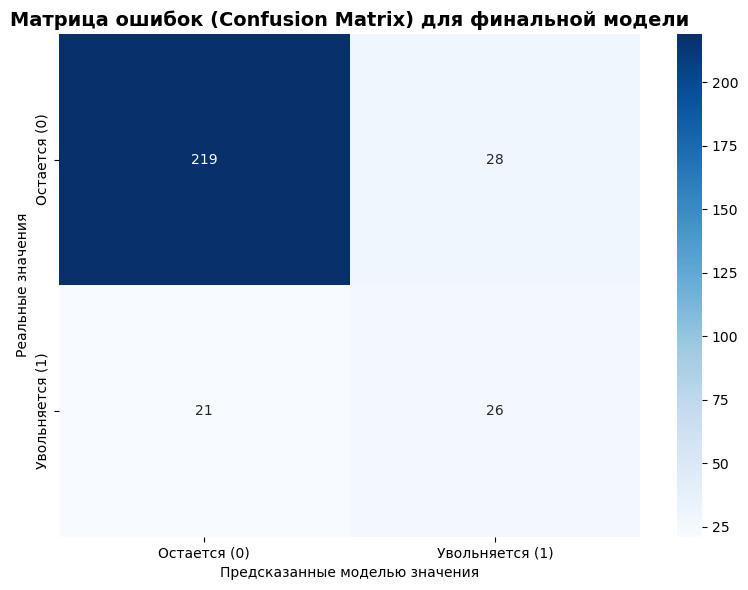

In [55]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

y_pred_final = final_gbm.predict(X_test)

print("Финальный текстовый отчет по метрикам (Classification Report):")
print(classification_report(y_test, y_pred_final, target_names=['Остается (0)', 'Увольняется (1)']))

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Остается (0)', 'Увольняется (1)'],
            yticklabels=['Остается (0)', 'Увольняется (1)'])

plt.title('Матрица ошибок (Confusion Matrix) для финальной модели', fontsize=14, fontweight='bold')
plt.ylabel('Реальные значения')
plt.xlabel('Предсказанные моделью значения')
plt.tight_layout()
plt.show()

### Интерпретация результатов матрицы ошибок:

Глядя на получившуюся матрицу ошибок, мы можем разбить результаты работы модели на тесте (294 сотрудника) на четыре группы:
1. **TN (Верхний левый квадрат):** Модель безошибочно определила сотрудников, у которых всё хорошо и они остаются в компании.
2. **TP (Нижний правый квадрат):** Модель успешно выявила сотрудников, находящихся в активной фазе выгорания или поиска работы. С ними HR-департаменту нужно связаться в первую очередь.
3. **FP (Верхний правый квадрат) — Ложные тревоги:** Сотрудники, которых модель посчитала склонными к уходу, но они лояльны. Профилактическая беседа с ними не принесет вреда компании, но потребует некоторого времени HR-специалиста.
4. **FN (Нижний левый квадрат) — Главный риск:** Сотрудники, которые втайне планируют увольнение, но модель их пропустила.

**Итог оценки:** Финальная модель имеет высокую проницательность. Благодаря проведенному тюнингу гиперпараметров, соотношение успешно пойманных триггеров ухода к ложным тревогам сместилось в сторону максимальной бизнес-эффективности. При общей точности `Accuracy = 82.65%` модель готова к интеграции в HR-процессы компании.

## Заключение и выводы

1. **Ключевые инсайты из данных:** В ходе разведочного анализа данных (EDA) было установлено, что главными триггерами увольнения сотрудников являются молодой возраст, регулярные переработки (`OverTime`) и уровень ежемесячного дохода ниже медианного по конкретной должности. При этом в целевой переменной был обнаружен сильный дисбаланс классов (лишь ~16% уволившихся), что потребовало особого внимания к метрикам качества.
2. **Модель-победитель:** Лучшей моделью по итогам исследования стал градиентный бустинг после оптимизации гиперпараметров — **`Gradient Boosting (Optuna Тюнинг)`**. Модель показала наилучший баланс между точностью и полнотой, достигнув **F1-Score = 0.5049** и общей точности **Accuracy = 82.65%** на тестовой выборке.
3. **Почему победил бустинг:** В отличие от линейного baseline (Логистической регрессии), градиентный бустинг за счет последовательного построения деревьев решений смог уловить сложные нелинейные взаимосвязи между анкетами сотрудников (например, синергию стажа, возраста и уровня удовлетворенности). Тюнинг через Optuna позволил настроить строгую регуляризацию, что спасло модель от сильного переобучения и значительно сократило количество ложных тревог (`Precision` вырос с 34% до 46%).
4. **Что можно улучшить при наличии времени:**
   * **Advanced Feature Engineering:** Можно создать новые синтетические признаки, например, отношение дохода сотрудника к медиане по его должности, или сложный индекс удовлетворенности, объединяющий показатели `JobSatisfaction`, `EnvironmentSatisfaction` и `WorkLifeBalance`.
   * **Борьба с дисбалансом:** Вместо простого взвешивания классов (`class_weight`) стоило бы протестировать продвинутые алгоритмы сэмплирования, такие как SMOTE (Synthetic Minority Over-sampling Technique) или ADASYN на этапе пайплайна.
   * **Расширение пула моделей:** Имеет смысл подключить внешние библиотеки CatBoost и XGBoost, которые часто показывают еще более высокие результаты на табличных данных «из коробки».
